In [2]:
import pandas as pd

try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')

    df = train_df.copy()

    merged_df = pd.concat([train_df, test_df], ignore_index=True)

    print("Les DataFrames ont été chargés et concaténés avec succès.")
    print("Dimensions du DataFrame fusionné :", merged_df.shape)
    print("Aperçu des 5 premières lignes du DataFrame fusionné", merged_df.head())
except FileNotFoundError as e:
    print(f"Erreur : L’un des fichiers est introuvable. Veuillez vérifier que 'train.csv' et 'test.csv' se trouvent dans le bon répertoire. Détails: {e}")
except Exception as e:
    print(f"Une erreur inattendue s'est produite: {e}")


Les DataFrames ont été chargés et concaténés avec succès.
Dimensions du DataFrame fusionné : (12970, 14)
Aperçu des 5 premières lignes du DataFrame fusionné   PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0 

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")


J'analyse la target Transported afin de visualiser la répartition de la variable cible:

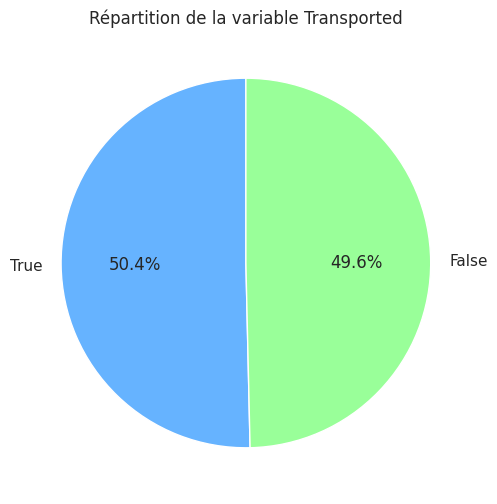

In [4]:
plt.figure(figsize=(6,6))
df['Transported'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff','#99ff99']
)
plt.title("Répartition de la variable Transported")
plt.ylabel("")
plt.show()


Ensuite, je cherche les corrélations entre catégories:

Je commence par homeplanet et transported:




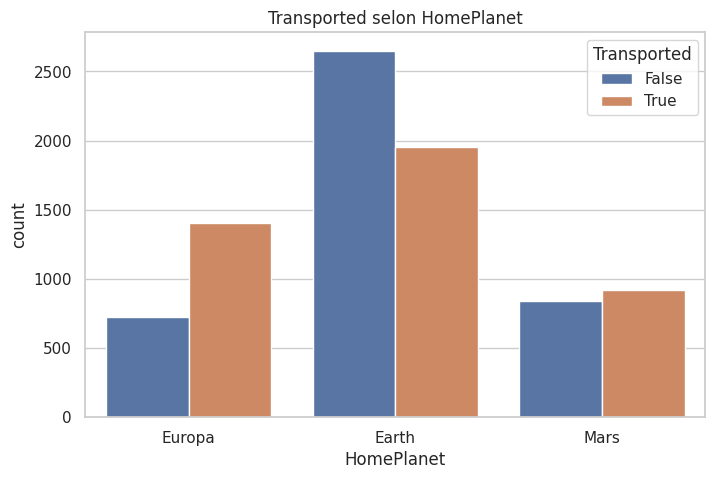

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='HomePlanet', hue='Transported')
plt.title("Transported selon HomePlanet")
plt.show()


Entre CryoSleep et Transported:

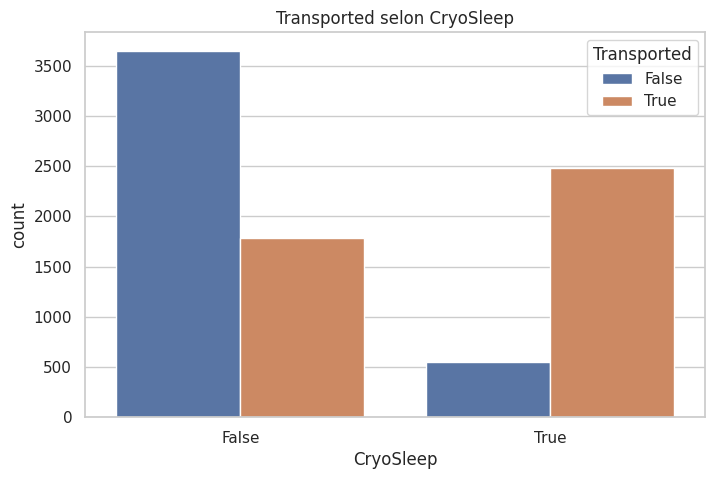

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='CryoSleep', hue='Transported')
plt.title("Transported selon CryoSleep")
plt.show()


In [7]:
# Destination et Transported:

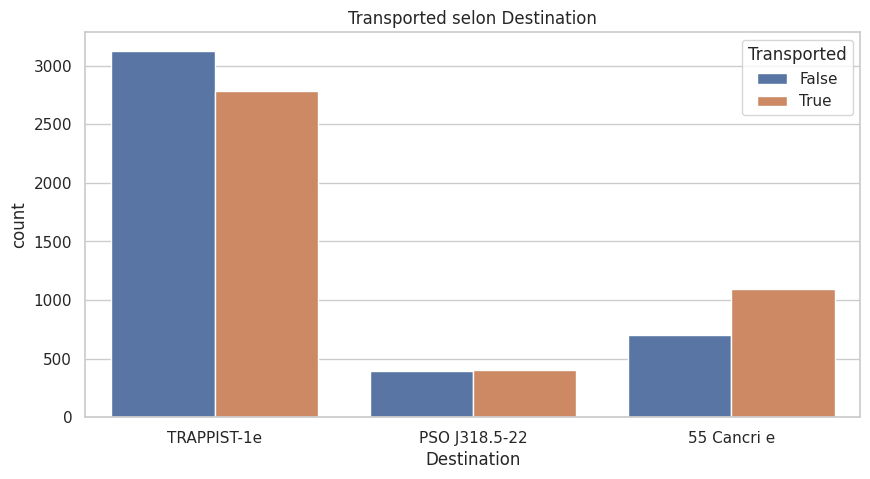

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Destination', hue='Transported')
plt.title("Transported selon Destination")
plt.show()


In [9]:
# Extraction de la variable cabin:

In [10]:
df[['Deck','CabinNum','Side']] = df['Cabin'].str.split('/', expand=True)


Deck-Transported:

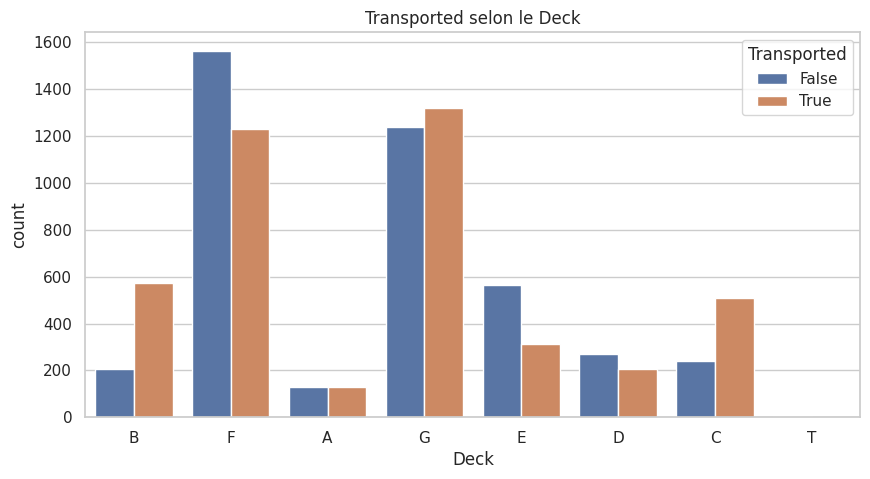

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Deck', hue='Transported')
plt.title("Transported selon le Deck")
plt.show()


Slide-Transported:

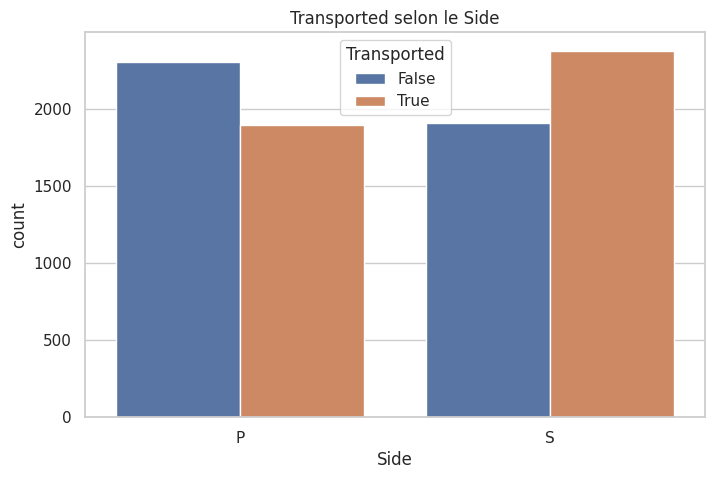

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Side', hue='Transported')
plt.title("Transported selon le Side")
plt.show()


Analyse numérique:

Distribution de l'âge selon Transport:

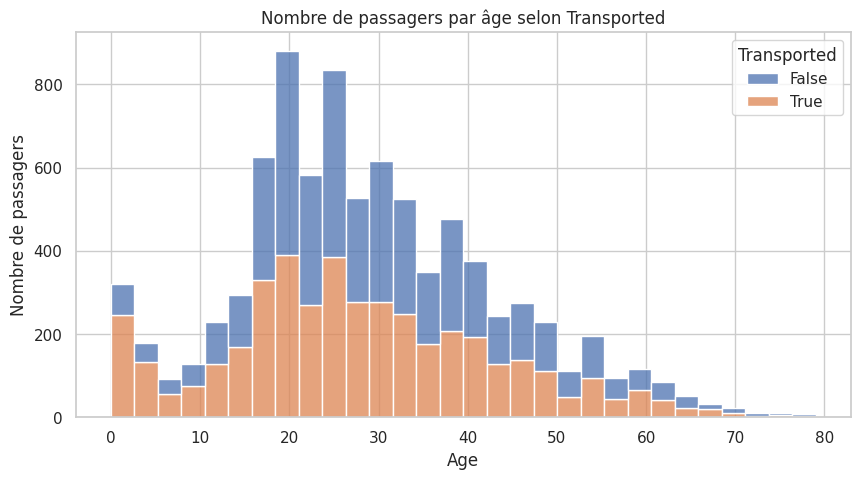

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Age', hue='Transported', bins=30, multiple="stack")
plt.title("Nombre de passagers par âge selon Transported")
plt.xlabel("Age")
plt.ylabel("Nombre de passagers")
plt.show()


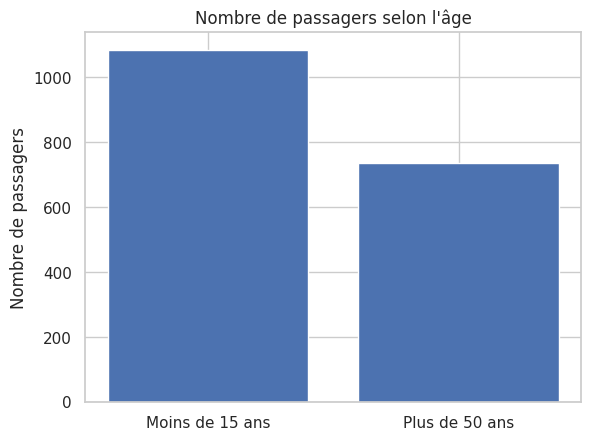

In [14]:
ages = {
    "Moins de 15 ans": (df['Age'] < 15).sum(),
    "Plus de 50 ans": (df['Age'] > 50).sum()
}

plt.bar(ages.keys(), ages.values())
plt.title("Nombre de passagers selon l'âge")
plt.ylabel("Nombre de passagers")
plt.show()

Heatmap de corrélation de Pearson entre toutes les variables de dépenses (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck):

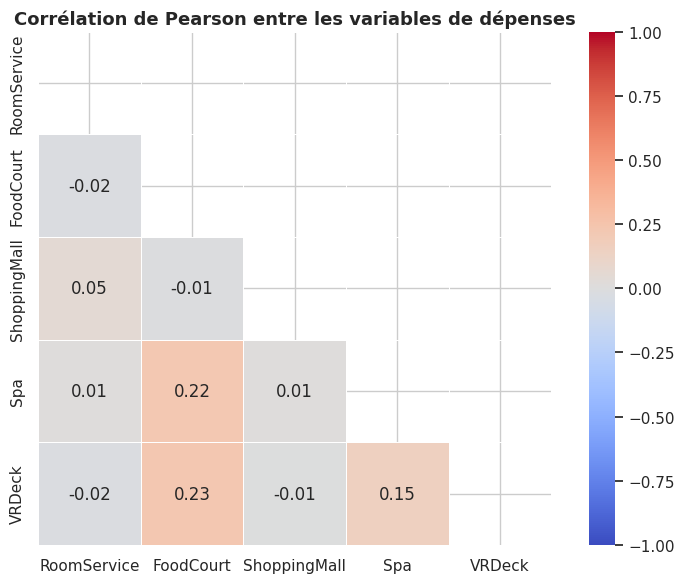

In [15]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

plt.figure(figsize=(8, 6))
corr_matrix = df[spending_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masque triangle supérieur
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    mask=mask,
    square=True,
    linewidths=0.5
)
plt.title("Corrélation de Pearson entre les variables de dépenses", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


 Boxplots pour identifier les valeurs aberrantes (outliers) sur les dépenses totales:

In [16]:
df['TotalSpending'] = df[spending_cols].sum(axis=1)


/tmp/ipykernel_143/4293937982.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


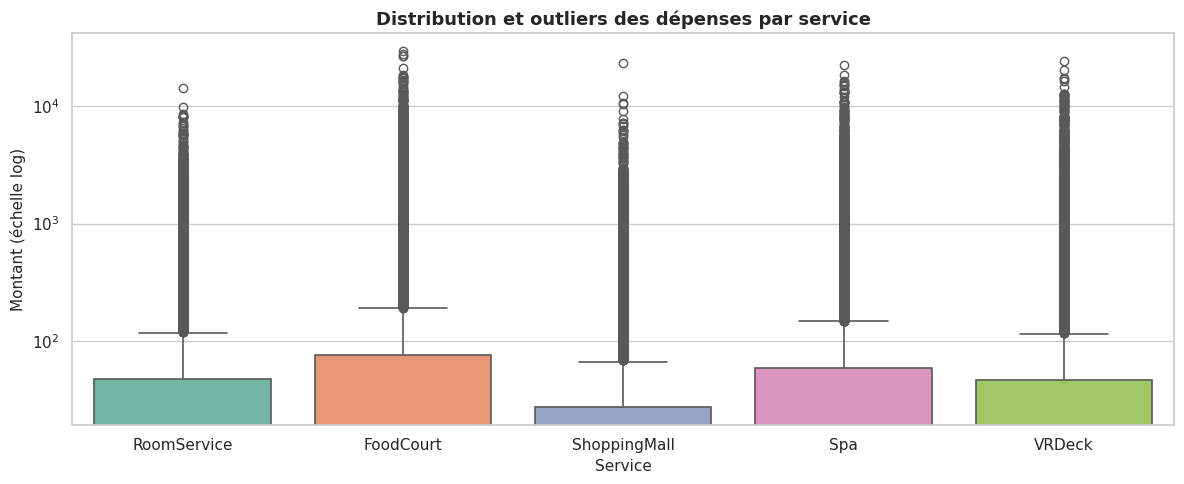

In [17]:
spending_melted = df[spending_cols].melt(var_name='Service', value_name='Montant')

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=spending_melted,
    x='Service', y='Montant',
    palette='Set2', linewidth=1.2
)
plt.yscale('log')
plt.title("Distribution et outliers des dépenses par service", fontsize=13, fontweight='bold')
plt.xlabel("Service", fontsize=11)
plt.ylabel("Montant (échelle log)", fontsize=11)
plt.tight_layout()
plt.show()


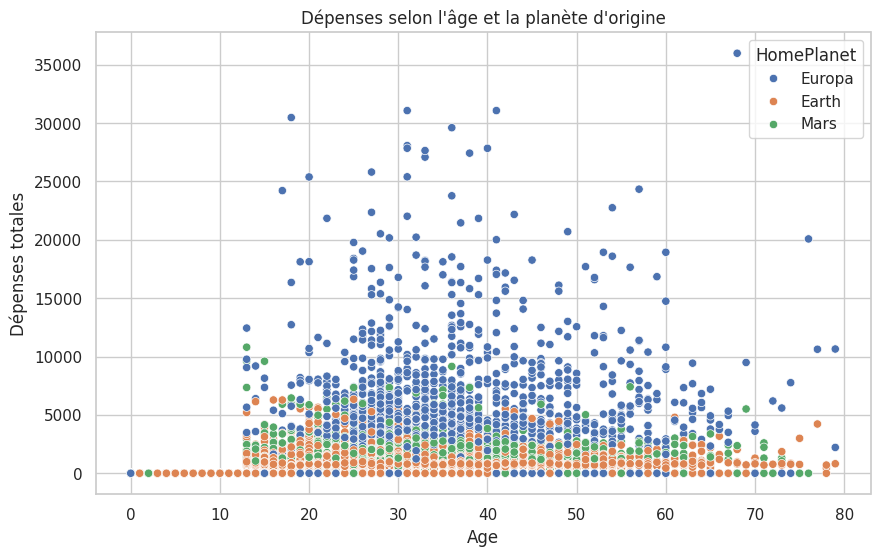

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='TotalSpending', hue='HomePlanet')

plt.title("Dépenses selon l'âge et la planète d'origine")
plt.xlabel("Age")
plt.ylabel("Dépenses totales")
plt.show()

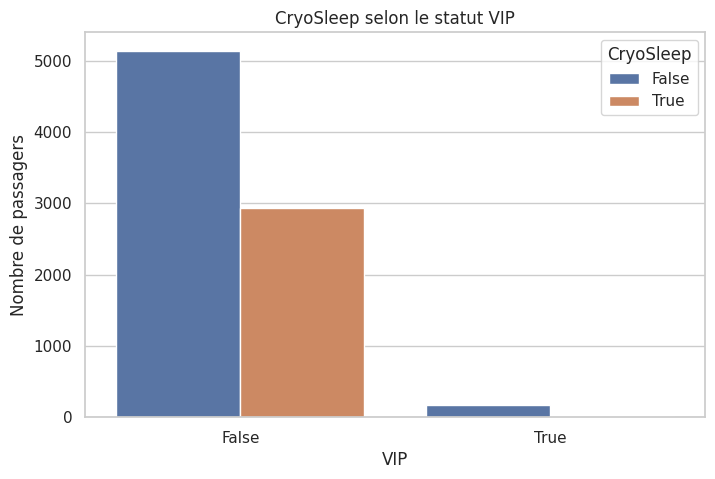

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='VIP', hue='CryoSleep')

plt.title("CryoSleep selon le statut VIP")
plt.xlabel("VIP")
plt.ylabel("Nombre de passagers")
plt.show()

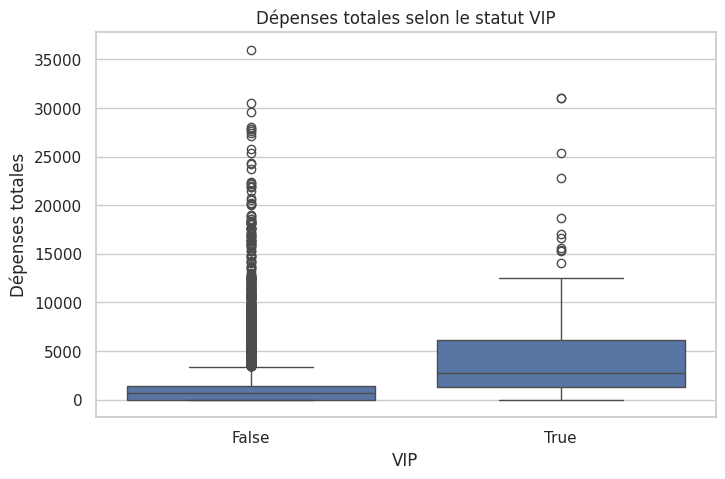

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='VIP', y='TotalSpending')

plt.title("Dépenses totales selon le statut VIP")
plt.xlabel("VIP")
plt.ylabel("Dépenses totales")
plt.show()

In [21]:
age_moyen_deck = df.groupby('Deck')['Age'].mean()

print(age_moyen_deck)

Deck
A    35.161943
B    33.622715
C    34.886145
D    33.518201
E    30.068925
F    28.430495
G    24.062775
T    37.000000
Name: Age, dtype: float64


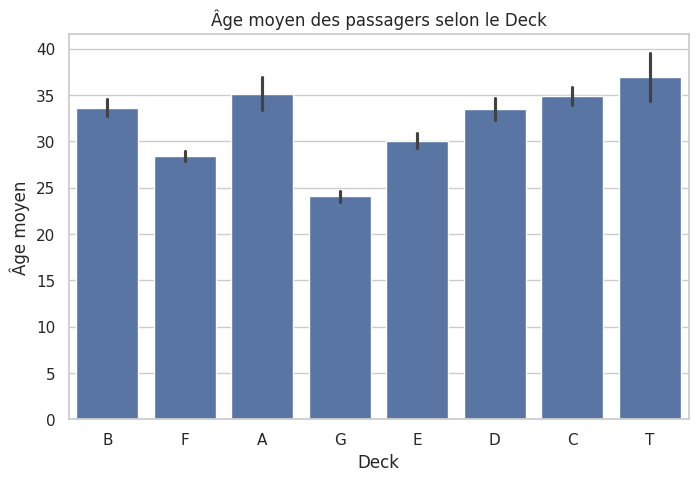

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Deck', y='Age')

plt.title("Âge moyen des passagers selon le Deck")
plt.xlabel("Deck")
plt.ylabel("Âge moyen")
plt.show()

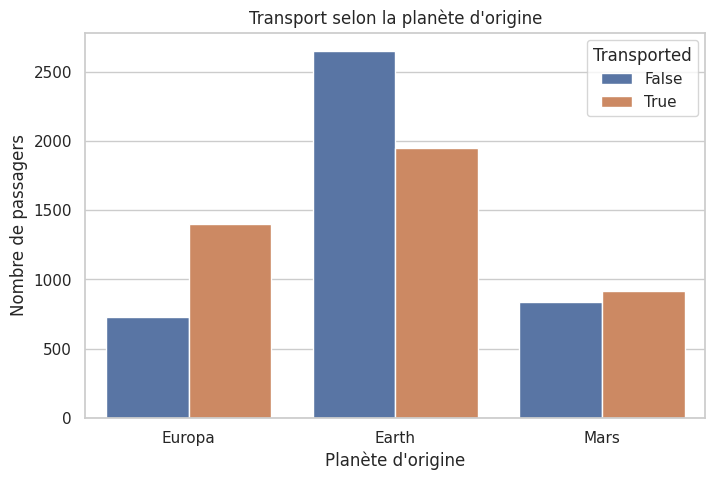

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='HomePlanet', hue='Transported')

plt.title("Transport selon la planète d'origine")
plt.xlabel("Planète d'origine")
plt.ylabel("Nombre de passagers")
plt.show()

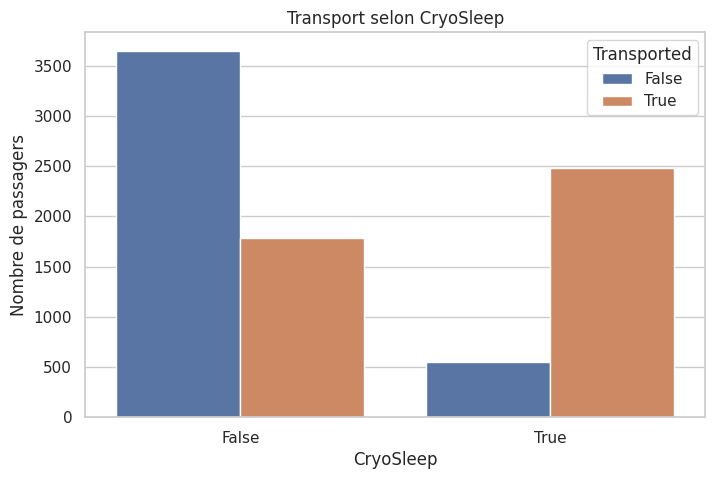

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='CryoSleep', hue='Transported')

plt.title("Transport selon CryoSleep")
plt.xlabel("CryoSleep")
plt.ylabel("Nombre de passagers")
plt.show()

Dépenses selon le transport:

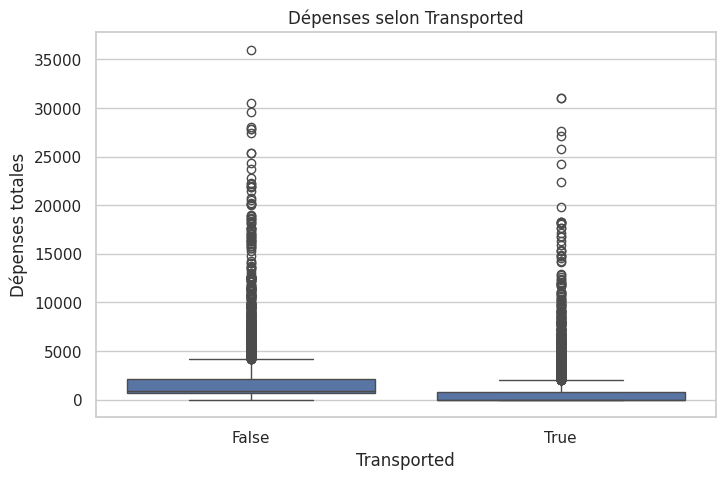

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Transported', y='TotalSpending')

plt.title("Dépenses selon Transported")
plt.xlabel("Transported")
plt.ylabel("Dépenses totales")
plt.show()

Transport selon le deck:

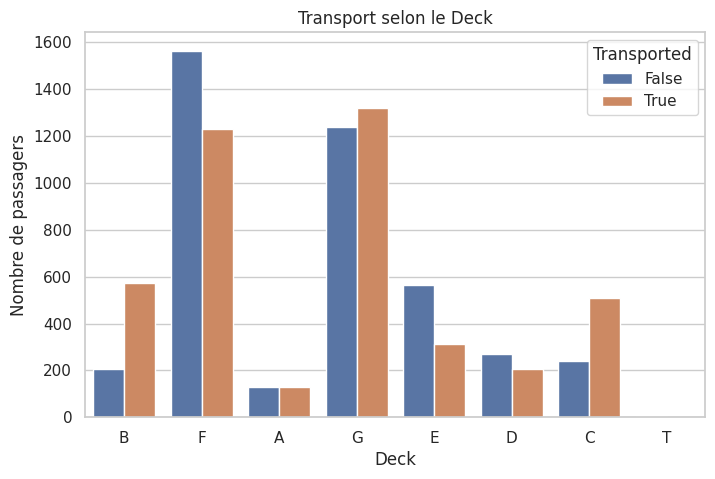

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Deck', hue='Transported')

plt.title("Transport selon le Deck")
plt.xlabel("Deck")
plt.ylabel("Nombre de passagers")
plt.show()

Taille des groupes de passagers:

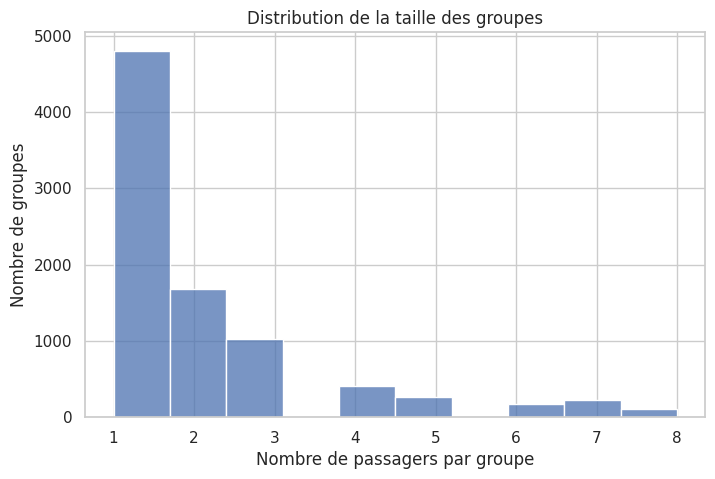

In [27]:
df['Group_Id'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
df['GroupSize'] = df.groupby('Group_Id')['PassengerId'].transform('count')

plt.figure(figsize=(8,5))
sns.histplot(df['GroupSize'], bins=10)

plt.title("Distribution de la taille des groupes")
plt.xlabel("Nombre de passagers par groupe")
plt.ylabel("Nombre de groupes")
plt.show()

In [28]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,CabinNum,Side,TotalSpending,Group_Id,GroupSize
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0,P,0.0,0001,1
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0,S,736.0,0002,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0,S,10383.0,0003,2
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0,S,5176.0,0003,2
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1,S,1091.0,0004,1


In [29]:
cols_to_drop = [
    'PassengerId', 'Cabin', 'Name',
    'Group_Id', 'GroupSize'
]

df = df.drop(columns=cols_to_drop)

print(f'Colonnes restantes ({len(df.columns)}) :', df.columns.tolist())
df.head()

Colonnes restantes (15) : ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'Deck', 'CabinNum', 'Side', 'TotalSpending']


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,CabinNum,Side,TotalSpending
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0,P,0.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0,S,736.0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0,S,10383.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0,S,5176.0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1,S,1091.0


<!-- Supprimer passengerID, cabin, Name, RoomService, FoodCourt, ShoppingMall, Spa, VrDeck, Destination -->

# 2/ Feature Engineering & Nettoyage


In [30]:
print('Valeurs manquantes avant nettoyage :')
print(df.isnull().sum()[df.isnull().sum() > 0])


Valeurs manquantes avant nettoyage :
HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Deck            199
CabinNum        199
Side            199
dtype: int64


In [31]:

num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Valeurs manquantes après nettoyage :')
print(df.isnull().sum())

Valeurs manquantes après nettoyage :
HomePlanet       0
CryoSleep        0
Destination      0
Age              0
VIP              0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
Transported      0
Deck             0
CabinNum         0
Side             0
TotalSpending    0
dtype: int64


/tmp/ipykernel_143/1178539239.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [32]:

bool_cols = df.select_dtypes(include='bool').columns.tolist()
for col in bool_cols:
    df[col] = df[col].astype(int)

cat_text_cols = df.select_dtypes(include='object').columns.tolist()
print('Colonnes encodées :', cat_text_cols)

df = pd.get_dummies(df, columns=cat_text_cols, drop_first=True)

print(f'\nShape après encodage : {df.shape}')
df.head(3)

Colonnes encodées : ['HomePlanet', 'Destination', 'Deck', 'CabinNum', 'Side']

Shape après encodage : (8693, 1838)


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,TotalSpending,...,CabinNum_991,CabinNum_992,CabinNum_993,CabinNum_994,CabinNum_995,CabinNum_996,CabinNum_997,CabinNum_998,CabinNum_999,Side_S
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,736.0,...,False,False,False,False,False,False,False,False,False,True
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,10383.0,...,False,False,False,False,False,False,False,False,False,True


In [33]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Transported'])
y = df['Transported']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

X_train : (6085, 1837)
X_test  : (2608, 1837)
y_train : (6085,)
y_test  : (2608,)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Normalisation terminée.')
print(f'Moyenne X_train (doit ≈ 0) : {X_train_scaled.mean():.4f}')
print(f'Std X_train    (doit ≈ 1) : {X_train_scaled.std():.4f}')

Normalisation terminée.
Moyenne X_train (doit ≈ 0) : -0.0000
Std X_train    (doit ≈ 1) : 0.9682


In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [36]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy sur le jeu de test : {acc:.4f} ({acc*100:.2f}%)')
print()
print(classification_report(y_test, y_pred, target_names=['Not Transported', 'Transported']))

Accuracy sur le jeu de test : 0.7435 (74.35%)

                 precision    recall  f1-score   support

Not Transported       0.71      0.81      0.76      1289
    Transported       0.78      0.68      0.73      1319

       accuracy                           0.74      2608
      macro avg       0.75      0.74      0.74      2608
   weighted avg       0.75      0.74      0.74      2608



In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}

clf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

clf_grid.fit(X_train, y_train)

print(f'Meilleurs paramètres : {clf_grid.best_params_}')
print(f'Meilleure accuracy CV : {clf_grid.best_score_:.4f} ({clf_grid.best_score_*100:.2f}%)')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Meilleurs paramètres : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Meilleure accuracy CV : 0.8002 (80.02%)


In [38]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
